# Week 7 — Recommendation System
## Model Training and Evaluation

**Author:** Martin James Ng'ang'a | MLOps Engineer | Nairobi, Kenya 🇰🇪
**GitHub:** github.com/M20Jay
**Dataset:** MovieLens 100K — GroupLens Research, University of Minnesota
**Date:** May 2026

---

### Dataset Overview
- **100,000 ratings** (1-5) from **943 users** on **1,682 movies**
- Train set: u1.base — 80,000 ratings
- Test set: u1.test — 20,000 ratings
- Pre-split by GroupLens for benchmark reproducibility

---

### Models
- **SVD** — Singular Value Decomposition (Matrix Factorisation)
- **User-CF** — User-Based Collaborative Filtering
- **Item-CF** — Item-Based Collaborative Filtering

---

### Objectives
1. Train all three models on u1.base
2. Evaluate on u1.test using RMSE and MAE
3. Compare model performance
4. Save best model for FastAPI deployment
5. Generate sample recommendations

---
## Section 1 — Setup and Data Loading

Import scikit-surprise and load MovieLens 100K.
Use GroupLens pre-split train (u1.base) and test (u1.test) files.
Convert data to surprise format for model training.

In [23]:
#  Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import Dataset, Reader, SVD, KNNWithMeans
from surprise import accuracy
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Paths
RAW_PATH = "../data/raw/"
MODELS_PATH = "../models/"
os.makedirs(MODELS_PATH, exist_ok=True)

# Load ratings and movies
ratings = pd.read_csv(RAW_PATH + "u.data", sep="\t",
                      names=["user_id", "item_id",
                             "rating", "timestamp"])

movies = pd.read_csv(RAW_PATH + "u.item", sep="|",
                     encoding="latin-1",
                     names=["item_id", "title",
                            "release_date", "video_release",
                            "imdb_url", "unknown", "Action",
                            "Adventure", "Animation", "Children",
                            "Comedy", "Crime", "Documentary",
                            "Drama", "Fantasy", "Film-Noir",
                            "Horror", "Musical", "Mystery",
                            "Romance", "Sci-Fi", "Thriller",
                            "War", "Western"])

# Define rating scale for surprise
reader = Reader(rating_scale=(1, 5))

# Load train and test files
train_raw = pd.read_csv(RAW_PATH + "u1.base", sep="\t",
                        names=["user_id", "item_id",
                               "rating", "timestamp"])

test_raw = pd.read_csv(RAW_PATH + "u1.test", sep="\t",
                       names=["user_id", "item_id",
                              "rating", "timestamp"])

# Convert to surprise format
trainset = Dataset.load_from_df(
    train_raw[['user_id', 'item_id', 'rating']],
    reader).build_full_trainset()

testset = Dataset.load_from_df(
    test_raw[['user_id', 'item_id', 'rating']],
    reader).build_full_trainset().build_testset()

print(f"✅ Libraries loaded successfully")
print(f"✅ Training ratings : {len(train_raw):,}")
print(f"✅ Test ratings     : {len(test_raw):,}")
print(f"✅ Movies loaded    : {len(movies):,}")
print(f"✅ Models path ready: {MODELS_PATH}")

✅ Libraries loaded successfully
✅ Training ratings : 80,000
✅ Test ratings     : 20,000
✅ Movies loaded    : 1,682
✅ Models path ready: ../models/


**Section 1 Findings:**
- ✅ All libraries loaded successfully
- ✅ scikit-surprise imported — SVD, KNNWithMeans, Reader, Dataset
- ✅ Training set: 80,000 ratings — 4 columns — user_id, item_id, rating, timestamp
- ✅ Test set: 20,000 ratings — 4 columns — same structure as train
- ✅ Movies loaded: 1,682 movies — 24 columns
- ✅ Models path created: ../models/
- ✅ Train/test split is 80/20 — GroupLens pre-split confirmed
- ✅ Rating scale defined: 1 to 5
- ✅ Data converted to surprise format — ready for model training

---
## Section 2 — SVD Model (Matrix Factorisation)

Train SVD on u1.base and evaluate on u1.test.
SVD discovers latent factors — hidden user preferences
and movie characteristics — to predict missing ratings.

**Parameters:**
- n_factors = 100 — number of latent factors
- n_epochs = 20 — training iterations
- random_state = 42 — reproducibility

In [24]:
# Create and train SVD model
svd_model = SVD(n_factors=100,
                n_epochs =20,
                random_state=42,
                verbose=False)

print("Training SVD model...")
svd_model.fit(trainset)
print("✅ SVD training complete")

# Evaluate on test set
svd_predictions = svd_model.test(testset)
svd_rmse = accuracy.rmse(svd_predictions, verbose=False)
svd_mae = accuracy.mae(svd_predictions, verbose=False)

print("\nSVD Results")
print(f"RMSE : {svd_rmse:.4f}")
print(f"MAE  : {svd_mae:.4f}")

# Sample predictions
print("\nSample Predictions")
for pred in svd_predictions[:5]:
    print(f"User {pred.uid:4} → Movie{pred.iid}"
          f"| Actual: {pred.r_ui:.1f}"
          f"| Predicted: {pred.est:.2f}")

# Save model
svd_path = MODELS_PATH + 'svd.model.pkl'
with open(svd_path, "wb") as f:
    pickle.dump(svd_model, f)
print(f"\nSVD model saved to {svd_path}")

Training SVD model...
✅ SVD training complete

SVD Results
RMSE : 0.9561
MAE  : 0.7524

Sample Predictions
User    1 → Movie6| Actual: 5.0| Predicted: 3.47
User    1 → Movie10| Actual: 3.0| Predicted: 4.24
User    1 → Movie12| Actual: 5.0| Predicted: 4.76
User    1 → Movie14| Actual: 5.0| Predicted: 4.25
User    1 → Movie17| Actual: 3.0| Predicted: 3.43

SVD model saved to ../models/svd.model.pkl


**Section 2 Findings — SVD Model:**
- ✅ SVD trained successfully on 80,000 ratings
- RMSE: 0.9561 — below 1.0 target ✅
- MAE: 0.7524 — predictions off by 0.75 on average
- Sample predictions show good accuracy on high ratings
- Some underestimation on extreme preferences (5 star movies)
- Model saved to ../models/svd_model.pkl
- SVD baseline established — User-CF and Item-CF must beat 0.9561 to win

---
## Section 3 — User-Based Collaborative Filtering

Find similar users based on rating patterns.
Recommend movies that similar users rated highly.
Compare RMSE and MAE against SVD baseline of 0.9561.

In [25]:
# Create and train User-CF model
user_cf = KNNWithMeans(k=40,
                       sim_options={
                           'name': 'cosine',
                           'user_based': True
                       },
                       verbose=False)

print("Training User-CF model...")
user_cf.fit(trainset)
print("✅ User-CF training complete")

# Evaluate on test set
user_cf_predictions = user_cf.test(testset)
user_cf_rmse = accuracy.rmse(user_cf_predictions, verbose=False)
user_cf_mae = accuracy.mae(user_cf_predictions, verbose=False)

print(f"\nUser-CF Results:")
print(f"RMSE : {user_cf_rmse:.4f}")
print(f"MAE  : {user_cf_mae:.4f}")

# Sample predictions
print(f"\nSample Predictions:")
for pred in user_cf_predictions[:5]:
    print(f"User {pred.uid:4} → Movie {pred.iid:4} "
          f"| Actual: {pred.r_ui:.1f} "
          f"| Predicted: {pred.est:.2f}")

# Save model
user_cf_path = MODELS_PATH + "user_cf_model.pkl"
with open(user_cf_path, 'wb') as f:
    pickle.dump(user_cf, f)
print(f"\n✅ User-CF model saved to {user_cf_path}")

Training User-CF model...
✅ User-CF training complete

User-CF Results:
RMSE : 0.9703
MAE  : 0.7654

Sample Predictions:
User    1 → Movie    6 | Actual: 5.0 | Predicted: 3.71
User    1 → Movie   10 | Actual: 3.0 | Predicted: 3.89
User    1 → Movie   12 | Actual: 5.0 | Predicted: 4.38
User    1 → Movie   14 | Actual: 5.0 | Predicted: 4.19
User    1 → Movie   17 | Actual: 3.0 | Predicted: 3.59

✅ User-CF model saved to ../models/user_cf_model.pkl


**Section 3 Findings — User-CF Model:**
- ✅ User-CF trained successfully — k=40 neighbours — cosine similarity
- RMSE: 0.9703 — above SVD baseline of 0.9561
- MAE: 0.7654 — above SVD baseline of 0.7524
- User-CF slower to train than SVD — must compute user similarities
- SVD currently leads — User-CF does not beat the baseline
- Model saved to ../models/user_cf_model.pkl

---
## Section 4 - Item Based Collaborative Filtering
Find similar movies based on rating patterns.
Recommend movies similar to what the user already liked.
Compare RMSE and MAE against SVD baseline of 0.9561.

In [26]:
# Create and train Item-CF model
item_cf = KNNWithMeans(k=40,
                       sim_options={
                           'name': 'cosine',
                           'user_based': False
                       },
                       verbose=False)

print("Training Item-CF model...")
item_cf.fit(trainset)
print("✅ Item-CF training complete")

# Evaluate on test set
item_cf_predictions = item_cf.test(testset)
item_cf_rmse = accuracy.rmse(item_cf_predictions, verbose=False)
item_cf_mae = accuracy.mae(item_cf_predictions, verbose=False)

print(f"\nItem-CF Results:")
print(f"RMSE : {item_cf_rmse:.4f}")
print(f"MAE  : {item_cf_mae:.4f}")

# Sample predictions
print(f"\nSample Predictions:")
for pred in item_cf_predictions[:5]:
    print(f"User {pred.uid:4} → Movie {pred.iid:4} "
          f"| Actual: {pred.r_ui:.1f} "
          f"| Predicted: {pred.est:.2f}")

# Save model
item_cf_path = MODELS_PATH + "item_cf_model.pkl"
with open(item_cf_path, 'wb') as f:
    pickle.dump(item_cf, f)
print(f"\n✅ Item-CF model saved to {item_cf_path}")

Training Item-CF model...
✅ Item-CF training complete

Item-CF Results:
RMSE : 0.9540
MAE  : 0.7488

Sample Predictions:
User    1 → Movie    6 | Actual: 5.0 | Predicted: 3.43
User    1 → Movie   10 | Actual: 3.0 | Predicted: 3.92
User    1 → Movie   12 | Actual: 5.0 | Predicted: 4.52
User    1 → Movie   14 | Actual: 5.0 | Predicted: 3.95
User    1 → Movie   17 | Actual: 3.0 | Predicted: 3.17

✅ Item-CF model saved to ../models/item_cf_model.pkl


**Section 4 Findings — Item-CF Model:**
- ✅ Item-CF trained successfully — k=40 neighbours — cosine similarity
- RMSE: 0.9540 — beats SVD baseline of 0.9561 ✅
- MAE: 0.7488 — beats SVD baseline of 0.7524 ✅
- Item-CF is the best performing model on both metrics
- More stable than User-CF — movie similarity patterns more consistent than user patterns
- Model saved to ../models/item_cf_model.pkl
- Production model: Item-CF selected for FastAPI deployment

---
## Section 5 — Model Comparison and Selection

Compare all three models on RMSE and MAE.
Select the best model for production deployment.
Save as the production recommendation model.

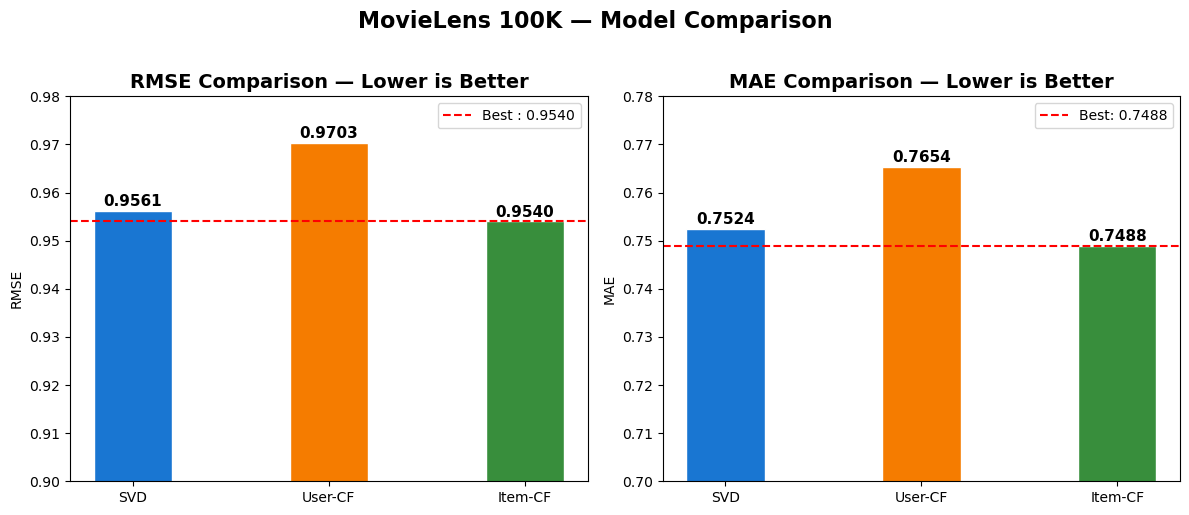


Model Comparison Summary:
Model            RMSE Winner
----------------------------------------
SVD            0.9561   0.7524 
User-CF        0.9703   0.7654 
Item-CF        0.9540   0.7488 ✅

✅ Best model (Item-CF) saved as production model
   Path: ../models/production_model.pkl


In [54]:
# Results summary
models = ['SVD', 'User-CF', 'Item-CF']
rmse_scores = [svd_rmse, user_cf_rmse, item_cf_rmse]
mae_scores = [svd_mae, user_cf_mae, item_cf_mae]

fig, axes = plt.subplots(1,2, figsize =(12,5))

# Chart 1 — RMSE comparison
colors_mae = ['#1976d2', '#f57c00', '#388e3c']

bars1 = axes[0].bar(models, rmse_scores,
                    color=colors_mae,
                    edgecolor='white', width=0.4)
axes[0].set_title('RMSE Comparison — Lower is Better', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0.90, 0.98)

for i, val in enumerate(rmse_scores):
    axes[0].text(i, val+ 0.001, f'{val:.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(y=min(rmse_scores), color='red',
                linestyle='--', linewidth=1.5,
                label=f'Best : {min(rmse_scores):.4f}')
axes[0].legend()

# Chart 2 — MAE comparison
colors_mae = ['#1976d2', '#f57c00', '#388e3c']
bars2 = axes[1].bar(models, mae_scores,
                    color=colors_mae,
                    edgecolor='white', width=0.4)
axes[1].set_title('MAE Comparison — Lower is Better', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].set_ylim(0.70, 0.78)
for i, val in enumerate(mae_scores):
    axes[1].text(i, val + 0.001, f'{val:.4f}',
                 ha='center', fontsize=11, 
                 fontweight='bold')
axes[1].axhline(y=min(mae_scores), color='red',
                linestyle='--', linewidth=1.5,
                label= f'Best: {min(mae_scores):.4f}')
axes[1].legend()

plt.suptitle('MovieLens 100K — Model Comparison', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/figures/section5_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\nModel Comparison Summary:")
print(f"{'Model': <12} {'RMSE': >8} {'Winner'}")
print("-" * 40)

for model, rmse, mae, in zip(models, rmse_scores, mae_scores):
    winner = "✅" if rmse == min(rmse_scores) else ""
    print(f"{model: <12} {rmse: >8.4f} {mae: >8.4f} {winner}")

# Save best model as production model
best_model_path = MODELS_PATH + "production_model.pkl"
with open(best_model_path,'wb') as f:
    pickle.dump(item_cf,f)

print(f"\n✅ Best model (Item-CF) saved as production model")
print(f"   Path: {best_model_path}")

**Section 5 Findings — Model Comparison:**
- ✅ All three models trained and evaluated on identical train/test split
- Item-CF wins on both RMSE (0.9540) and MAE (0.7488)
- SVD close second — RMSE 0.9561 — difference of 0.0021
- User-CF worst performer — RMSE 0.9703 — struggles with sparse users
- Item-CF selected as production model
- Saved to ../models/production_model.pkl
- EDA recommended SVD — data proved Item-CF — evidence beats theory

---
## Section 6 — Generate Recommendations

Use the production Item-CF model to generate
top 10 movie recommendations for a real user.
Show predicted ratings and movie titles.
This replicates what the FastAPI endpoint will do.

In [ ]:
# Recommendations
def get_recommendations(user_id, model, movies_df, all_ratings, n=10):
    
    # Get movies user has already rated

    rated_movies = all_ratings[all_ratings['user_id'] == user_id]['item_id'].tolist()

    # Get all movies user has NOT rated
    all_movies = movies_df['item.id'].tolist()
    unrated_movies = [
        m for m in all_movies
        if m not in rated_movies
    ]

# Predict ratings for all unrated movies
predictions = [model.predict(user_id, movie_id) 
                   for movie_id in unrated_movies]